In [1]:
import numpy as np
import pandas as pd
import os
from collections import defaultdict
from shutil import copy
from shutil import copytree, rmtree

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
import torch
print(torch.__version__)
print("GPU Available:", torch.cuda.is_available())

2.5.1+cu121
GPU Available: True


In [3]:
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


Dataset Loading

In [4]:
import os

dataset_path = "C:/Users/CHANDANI/food classification/indian-food/dataset/Dataset"
print(os.listdir(dataset_path))

['test', 'train', 'val']


In [62]:
os.listdir('C:/Users/CHANDANI/food classification/indian-food/dataset/Dataset/train')

['adhirasam',
 'aloo_gobi',
 'aloo_matar',
 'aloo_methi',
 'aloo_shimla_mirch',
 'aloo_tikki',
 'anarsa',
 'ariselu',
 'bandar_laddu',
 'basundi',
 'bhatura',
 'bhindi_masala',
 'biryani',
 'boondi',
 'burger',
 'butter_chicken',
 'butter_naan',
 'chai',
 'chak_hao_kheer',
 'cham_cham',
 'chana_masala',
 'chapati',
 'chhena_kheeri',
 'chicken_razala',
 'chicken_tikka',
 'chicken_tikka_masala',
 'chikki',
 'chole_bhature',
 'daal_baati_churma',
 'daal_puri',
 'dal_makhani',
 'dal_tadka',
 'dharwad_pedha',
 'dhokla',
 'doodhpak',
 'double_ka_meetha',
 'dum_aloo',
 'fried_rice',
 'gajar_ka_halwa',
 'gavvalu',
 'ghevar',
 'gulab_jamun',
 'idli',
 'imarti',
 'jalebi',
 'kaathi_rolls',
 'kachori',
 'kadai_paneer',
 'kadhi_pakoda',
 'kajjikaya',
 'kakinada_khaja',
 'kalakand',
 'karela_bharta',
 'kofta',
 'kulfi',
 'kuzhi_paniyaram',
 'lassi',
 'ledikeni',
 'litti_chokha',
 'lyangcha',
 'maach_jhol',
 'makki_di_roti_sarson_da_saag',
 'malapua',
 'masala_dosa',
 'misi_roti',
 'misti_doi',
 'mo

Preperation of Data - 

In [5]:
base_path = "C:/Users/CHANDANI/food classification/indian-food/dataset/Dataset"

In [9]:
train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "val")
test_path  = os.path.join(base_path, "test")

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# TRAIN (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# TEST / VAL
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_path, transform=test_transform)
test_dataset  = datasets.ImageFolder(root=test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print("Classes:", num_classes)

Classes: 96


In [67]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Replace last layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# new model

small dataset use this


In [41]:
import torchvision.models as models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

# Freeze base layers
for param in model.features.parameters():
    param.requires_grad = False

 # 100 classes

In [42]:
# Unfreeze last few layers of features
for param in model.features[-4:].parameters():
    param.requires_grad = True

In [43]:
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, num_classes)
)

In [44]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [45]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.3
)

In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)#resnet

In [22]:
from PIL import Image

In [23]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

GPU Available: True
Device: cuda


In [ ]:
# model already defined
#Large dataset
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Actual training code


In [48]:

import torch
import torch.nn as nn
import torch.optim as optim

train_losses = []
train_accuracies = []
val_accuracies = []

epochs = 20

# 🔥 Early Stopping Setup
best_val_loss = float('inf')
best_val_acc = 0
patience = 5
counter = 0

for epoch in range(epochs):
    # ================= TRAIN =================
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ================= VALIDATION =================
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # ✅ Correct loss calculation
            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    val_accuracies.append(val_acc)

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    # ✅ Save best accuracy model (optional but useful)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_acc_model.pth")

    if counter >= patience:
        print("🚨 Early stopping triggered")
        break

    # ================= SCHEDULER =================
    scheduler.step(val_loss)

    # ================= PRINT =================
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}, LR: {current_lr:.6f}, "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

print("\n🔥 Training Complete!")

Epoch 1, LR: 0.001000, Train Loss: 3.4421, Train Acc: 0.1869, Val Acc: 0.3608, Val Loss: 2.3427
Epoch 2, LR: 0.001000, Train Loss: 2.1403, Train Acc: 0.4234, Val Acc: 0.4744, Val Loss: 1.8999
Epoch 3, LR: 0.001000, Train Loss: 1.7518, Train Acc: 0.5026, Val Acc: 0.5071, Val Loss: 1.7450
Epoch 4, LR: 0.001000, Train Loss: 1.4699, Train Acc: 0.5717, Val Acc: 0.5568, Val Loss: 1.6715
Epoch 5, LR: 0.001000, Train Loss: 1.2404, Train Acc: 0.6409, Val Acc: 0.5341, Val Loss: 1.7365
Epoch 6, LR: 0.001000, Train Loss: 1.0921, Train Acc: 0.6800, Val Acc: 0.5838, Val Loss: 1.6253
Epoch 7, LR: 0.001000, Train Loss: 0.9174, Train Acc: 0.7243, Val Acc: 0.5781, Val Loss: 1.6295
Epoch 8, LR: 0.001000, Train Loss: 0.7879, Train Acc: 0.7629, Val Acc: 0.5668, Val Loss: 1.6635
Epoch 9, LR: 0.000300, Train Loss: 0.7087, Train Acc: 0.7794, Val Acc: 0.6009, Val Loss: 1.6398
Epoch 10, LR: 0.000300, Train Loss: 0.4187, Train Acc: 0.8806, Val Acc: 0.6349, Val Loss: 1.3907
Epoch 11, LR: 0.000300, Train Loss: 0.3

In [73]:
for param in model.parameters():
    param.requires_grad = False

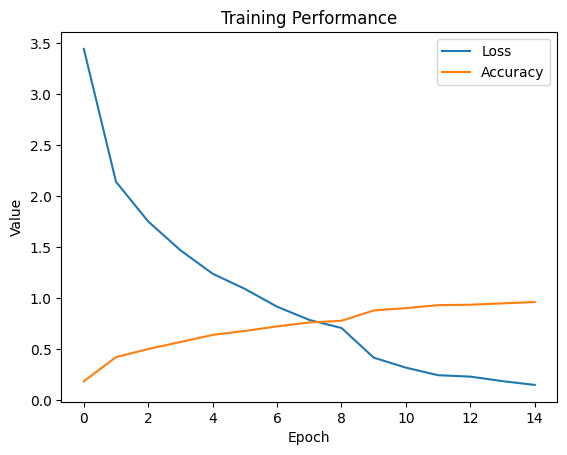

In [49]:
plt.plot(train_losses, label="Loss")
plt.plot(train_accuracies, label="Accuracy")
plt.legend()
plt.title("Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.show()

In [51]:
model.eval()
val_correct = 0
val_total = 0
val_loss = 0   # ✅ ADD THIS

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)   # ✅ ADD THIS
        val_loss += loss.item()             # ✅ ADD THIS

        _, preds = torch.max(outputs, 1)

        val_correct += (preds == labels).sum().item()
        val_total += labels.size(0)

val_acc = val_correct / val_total
val_loss = val_loss / len(val_loader)   # ✅ average loss

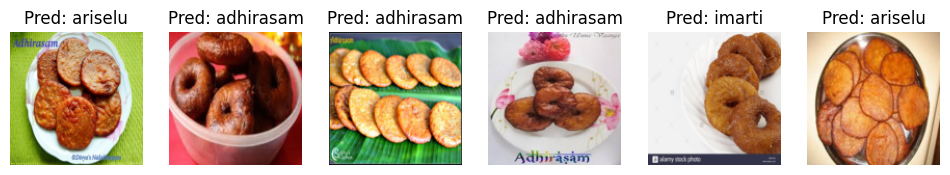

In [75]:
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

# show predictions
fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for i in range(6):
    img = images[i].cpu().permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {train_dataset.classes[preds[i]]}")
    axes[i].axis("off")

plt.show()

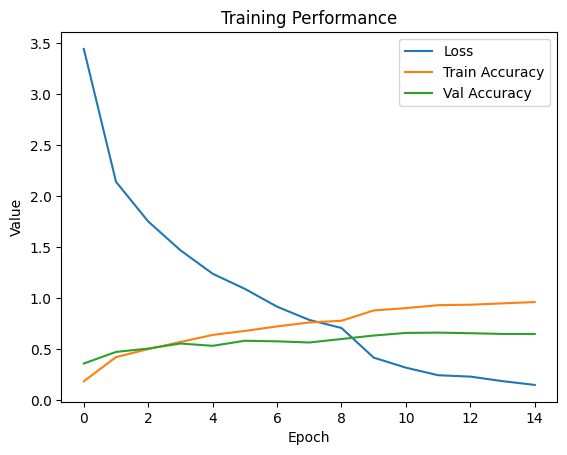

In [52]:
plt.plot(train_losses, label="Loss")
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")   # 👈 ADD THIS

plt.legend()
plt.title("Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.show()

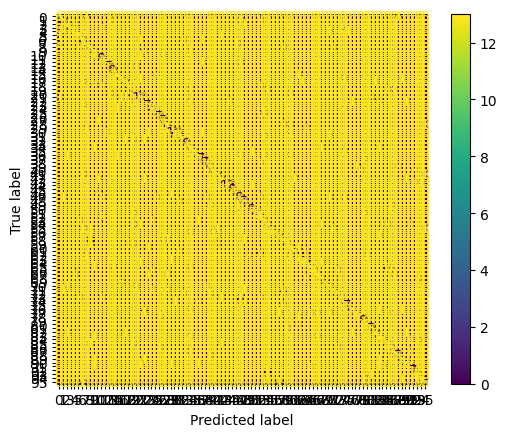

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [79]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_acc = test_correct / test_total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.5238693467336684


In [66]:
from PIL import Image
import torch

img_path = "C:/Users/CHANDANI/Downloads/Ras-Malai-Recipe.jpg"  # 👈 change this

image = Image.open(img_path).convert("RGB")

In [67]:
image = test_transform(image)   # same transform used in test
image = image.unsqueeze(0)      # add batch dimension
image = image.to(device)

In [68]:
model.eval()

with torch.no_grad():
    outputs = model(image)
    _, pred = torch.max(outputs, 1)

predicted_class = train_dataset.classes[pred.item()]
print("Prediction:", predicted_class)

Prediction: ras_malai


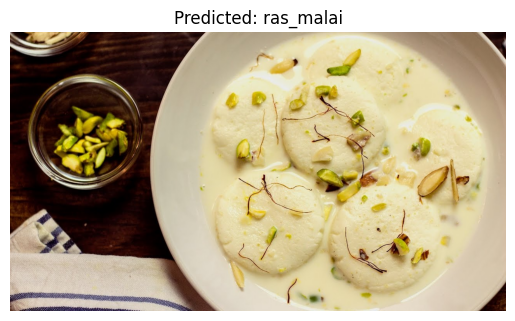

In [69]:
import matplotlib.pyplot as plt

plt.imshow(Image.open(img_path))
plt.title(f"Predicted: {train_dataset.classes[pred.item()]}")
plt.axis("off")
plt.show()

In [70]:
for i in range(50):
    img, label = test_dataset[i]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_input)
        _, pred = torch.max(outputs, 1)

    print("Actual:", test_dataset.classes[label],
          "Predicted:", test_dataset.classes[pred.item()])

Actual: adhirasam Predicted: ariselu
Actual: adhirasam Predicted: adhirasam
Actual: adhirasam Predicted: adhirasam
Actual: adhirasam Predicted: adhirasam
Actual: adhirasam Predicted: adhirasam
Actual: adhirasam Predicted: shankarpali
Actual: adhirasam Predicted: adhirasam
Actual: adhirasam Predicted: adhirasam
Actual: aloo_gobi Predicted: aloo_gobi
Actual: aloo_gobi Predicted: aloo_gobi
Actual: aloo_gobi Predicted: kadai_paneer
Actual: aloo_gobi Predicted: aloo_gobi
Actual: aloo_gobi Predicted: aloo_gobi
Actual: aloo_gobi Predicted: karela_bharta
Actual: aloo_gobi Predicted: aloo_gobi
Actual: aloo_gobi Predicted: boondi
Actual: aloo_matar Predicted: aloo_matar
Actual: aloo_matar Predicted: aloo_matar
Actual: aloo_matar Predicted: aloo_matar
Actual: aloo_matar Predicted: aloo_shimla_mirch
Actual: aloo_matar Predicted: aloo_gobi
Actual: aloo_matar Predicted: kadhi_pakoda
Actual: aloo_matar Predicted: aloo_gobi
Actual: aloo_matar Predicted: aloo_matar
Actual: aloo_methi Predicted: aloo_me

In [71]:
torch.save(model.state_dict(), "food_model.pth")

In [72]:
import torch
import torchvision.models as models
import torch.nn as nn

# Recreate model structure
model = models.mobilenet_v2(pretrained=False)

model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, num_classes)
)

# Load weights
model.load_state_dict(torch.load("food_model.pth"))
model.eval()

C:\Users\CHANDANI\food classification\torch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\CHANDANI\food classification\torch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\CHANDANI\AppData\Local\Temp\ipykernel_32028\3238992286.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, t

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [73]:
import json

with open("classes.json", "w") as f:
    json.dump(train_dataset.classes, f)

In [74]:
with open("classes.json", "r") as f:
    class_names = json.load(f)

In [ ]:
results = []

for i in range(50):
    img, label = test_dataset[i]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_input)
        _, pred = torch.max(outputs, 1)

    results.append({
        "actual": class_names[label],
        "predicted": class_names[pred.item()]
    })

# Save to file
import json
with open("results.json", "w") as f:
    json.dump(results, f, indent=4)